In [2]:
import csv

file_path = 'UserCarData.csv'

try:
    with open(file_path, mode='r', encoding='utf-8') as file:
        csv_reader = csv.reader(file)
        headers = next(csv_reader)  # Read header row
        print("Headers:", headers)

        for row in csv_reader:
            print(row)  # You can process each row here as needed

except FileNotFoundError:
    print(f"Error: The file at '{file_path}' was not found.")
except IOError:
    print("Error: There was an issue reading the file (possibly corrupted or inaccessible).")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Headers: ['Sales_ID', 'name', 'year', 'selling_price', 'km_driven', 'Region', 'State or Province', 'City', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats', 'sold']
['1', 'Maruti', '2014', '450000', '145500', 'East', 'District of Columbia', 'Washington', 'Diesel', 'Individual', 'Manual', 'First_Owner', '23.4', '1248', '74', '190Nm@ 2000rpm', '5', 'Y']
['2', 'Skoda', '2014', '370000', '120000', 'East', 'New York', 'New York City', 'Diesel', 'Individual', 'Manual', 'Second_Owner', '21.14', '1498', '103.52', '250Nm@ 1500-2500rpm', '5', 'Y']
['3', 'Honda', '2006', '158000', '140000', 'Central', 'Illinois', 'Chicago', 'Petrol', 'Individual', 'Manual', 'Third_Owner', '17.7', '1497', '78', '12.7@ 2,700(kgm@ rpm)', '5', 'Y']
['4', 'Hyundai', '2010', '225000', '127000', 'Central', 'Illinois', 'Chicago', 'Diesel', 'Individual', 'Manual', 'First_Owner', '23', '1396', '90', '22.4 kgm at 1750-2750rpm', '5', 'Y']
['5', 'Maruti', '2007', '130000', '1

['6257', 'Maruti', '2005', '110000', '50800', 'South', 'Arkansas', 'Conway', 'Petrol', 'Dealer', 'Manual', 'Second_Owner', '19.7', '796', '46.3', '62Nm@ 3000rpm', '5', 'N']
['6258', 'Maruti', '2017', '484999', '10000', 'South', 'Arkansas', 'Conway', 'Petrol', 'Dealer', 'Manual', 'First_Owner', '23.1', '998', '67.04', '90Nm@ 3500rpm', '5', 'N']
['6259', 'BMW', '2018', '5830000', '30000', 'South', 'Arkansas', 'Conway', 'Diesel', 'Individual', 'Automatic', 'First_Owner', '17.09', '2993', '261.4', '620Nm@ 2000-2500rpm', '4', 'N']
['6260', 'Maruti', '2012', '185000', '60000', 'South', 'Arkansas', 'Bentonville', 'Petrol', 'Individual', 'Manual', 'Second_Owner', '19.7', '796', '46.3', '62Nm@ 3000rpm', '5', 'N']
['6261', 'Hyundai', '2018', '665000', '40142', 'South', 'Arkansas', 'Benton', 'Diesel', 'Dealer', 'Manual', 'First_Owner', '24.4', '1120', '71', '180.4Nm@ 1750-2500rpm', '5', 'N']
['6262', 'Hyundai', '2019', '721000', '9400', 'South', 'Arkansas', 'Bentonville', 'Petrol', 'Dealer', 'Man

In [3]:
import pandas as pd

# File paths
input_file = 'UserCarData.csv'
output_file = 'cleanCSVData.csv'

try:
    # Load the data
    df = pd.read_csv(input_file)
    print("Initial columns:", df.columns.tolist())
    print("raw data shape:", df.shape)

    # Remove duplicates
    df.drop_duplicates(inplace=True)

    # Drop rows with any missing values
    df.dropna(inplace=True)

    # Standardize column names
    df.columns = [col.strip().replace(" ", "_").lower() for col in df.columns]

    # Rename selling_price to price for easier reference
    if 'selling_price' in df.columns:
        df.rename(columns={'selling_price': 'price'}, inplace=True)

    # Normalize column types
    for col in ['year', 'mileage', 'price']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Drop rows where conversion introduced NaNs
    df.dropna(subset=['year', 'mileage', 'price'], inplace=True)

    # Filter out unrealistic or invalid data
    df = df[(df['year'] <= 2025) & (df['mileage'] > 0)]

    print("Cleaned data shape:", df.shape)

    # Save to new CSV
    df.to_csv(output_file, index=False)
    print(f"✅ Cleaned data saved to: {output_file}")

except FileNotFoundError:
    print(f"❌ File not found: {input_file}")
except pd.errors.ParserError:
    print("❌ Error while parsing the CSV file.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")


Initial columns: ['Sales_ID', 'name', 'year', 'selling_price', 'km_driven', 'Region', 'State or Province', 'City', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats', 'sold']
raw data shape: (7906, 18)
Cleaned data shape: (7889, 18)
✅ Cleaned data saved to: cleanCSVData.csv


In [5]:
pip install mysql-connector-python


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import mysql.connector

# MySQL credentials
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='root',
    database='UsedCarsDB'
)

cursor = conn.cursor()


In [3]:
import pandas as pd
import mysql.connector

# Load cleaned data
df = pd.read_csv('cleanCSVData.csv')

# Connect to MySQL
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='root',
    database='UsedCarsDB'
)
cursor = conn.cursor()
#cursor.execute("DROP TABLE IF EXISTS used_cars")

# Insert rows
for _, row in df.iterrows():
    sql = """
    INSERT IGNORE INTO used_cars (
        sales_id, name, year, price, mileage, region, state_or_province, city,
        fuel, seller_type, transmission, owner, engine, max_power, torque, seats, sold
    )
    VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
    """
    values = (
        int(row['sales_id']),
        row['name'],
        int(row['year']),
        int(row['price']),
        float(row['mileage']),
        row['region'],
        row['state_or_province'],
        row['city'],
        row['fuel'],
        row['seller_type'],
        row['transmission'],
        row['owner'],
        row['engine'],
        row['max_power'],
        row['torque'],
        int(row['seats']) if not pd.isna(row['seats']) else None,
        bool(row['sold']) if not pd.isna(row['sold']) else None
    )
    cursor.execute(sql, values)

# Commit changes
conn.commit()
print("✅ Data inserted successfully!")

# Close connection
cursor.close()
conn.close()


✅ Data inserted successfully!


Summary Statistics:
          sales_id         year         price     km_driven      mileage  \
count  7889.000000  7889.000000  7.889000e+03  7.889000e+03  7889.000000   
mean   4069.532640  2013.987831  6.496753e+05  6.919859e+04    19.461709   
std    2345.775017     3.863460  8.134766e+05  5.682769e+04     3.938527   
min       1.000000  1994.000000  2.999900e+04  1.000000e+00     9.000000   
25%    2037.000000  2012.000000  2.700000e+05  3.500000e+04    16.780000   
50%    4075.000000  2015.000000  4.500000e+05  6.000000e+04    19.330000   
75%    6099.000000  2017.000000  6.900000e+05  9.550000e+04    22.320000   
max    8128.000000  2020.000000  1.000000e+07  2.360457e+06    42.000000   

            engine    max_power        seats  
count  7889.000000  7889.000000  7889.000000  
mean   1458.378628    91.588665     5.418050  
std     503.299977    35.731275     0.958526  
min     624.000000    32.800000     4.000000  
25%    1197.000000    68.050000     5.000000  
50%    1248.0

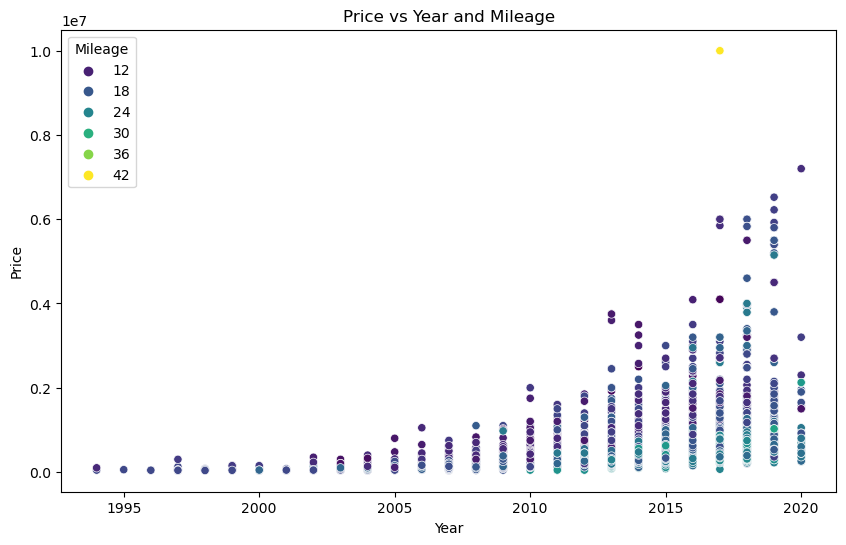

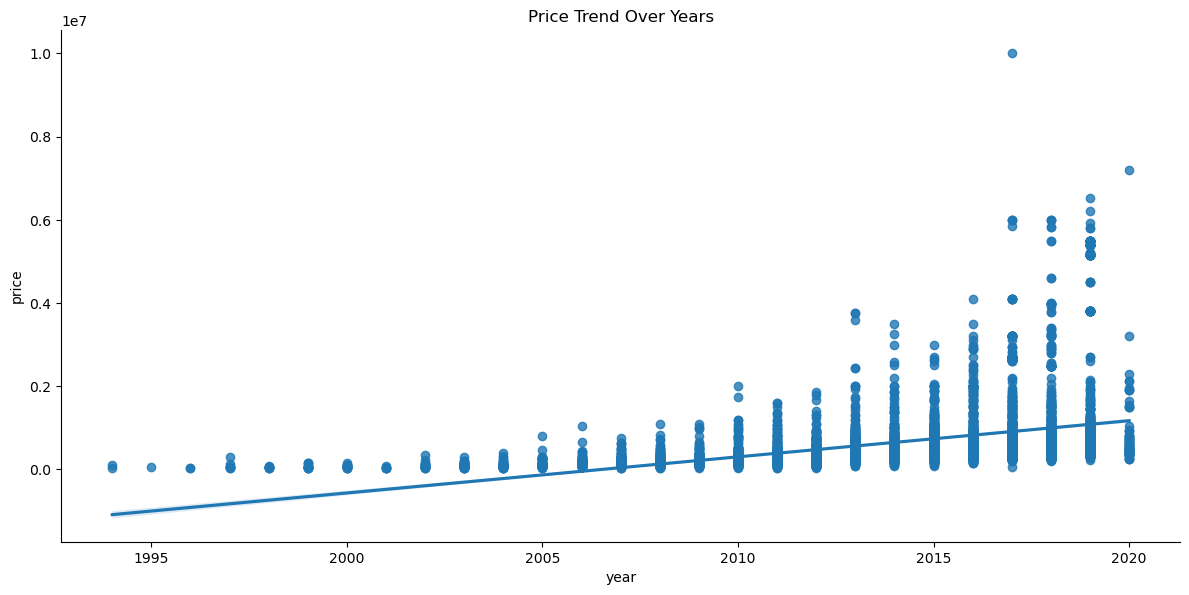

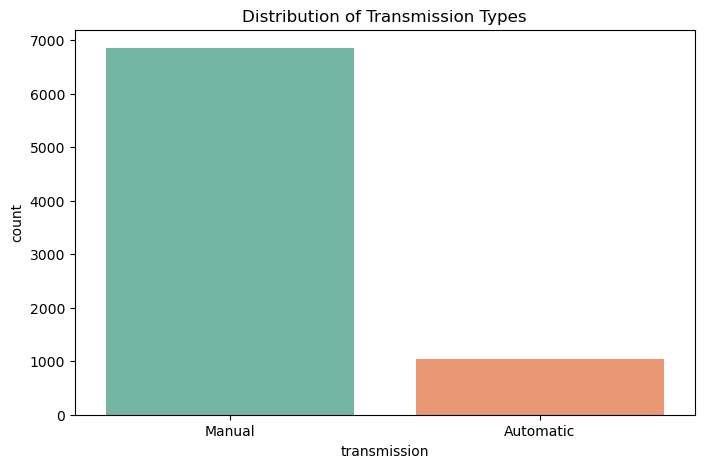

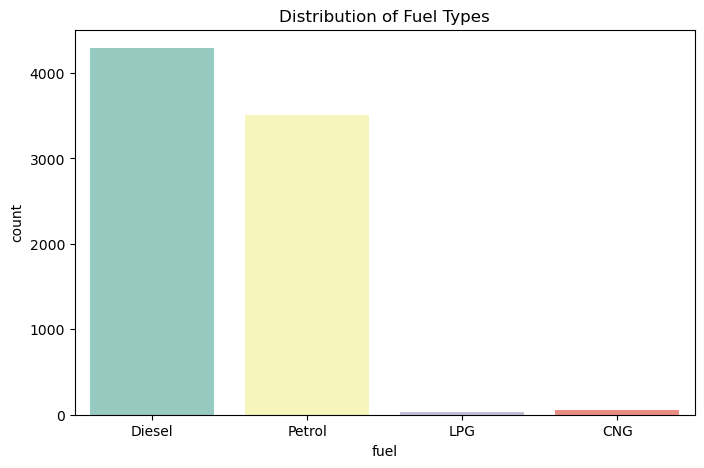

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 1. **Summary Statistics and Key Metrics**
# Getting basic statistics like mean, median, std, min, max for numeric columns
summary_stats = df.describe()

# You can also compute additional statistics like mode
mode_stats = df.mode()

# Printing the summary statistics and mode statistics
print("Summary Statistics:")
print(summary_stats)

print("\nMode Statistics:")
print(mode_stats)

# 2. **Top 10 Most Listed Car Models**
top_10_models = df['name'].value_counts().head(10)

print("\nTop 10 Most Listed Car Models:")
print(top_10_models)

# 3. **Cars Offering the Best Resale Value (Price-to-Mileage Ratio)**
df['price_to_mileage_ratio'] = df['price'] / df['mileage']
best_resale_value = df[['name', 'year', 'price', 'km_driven', 'price_to_mileage_ratio']] \
    .sort_values(by='price_to_mileage_ratio', ascending=True) \
    .head(10)

print("\nTop 10 Cars with Best Resale Value:")
print(best_resale_value)

# 4. **Market Trends (Price vs. Year and Mileage)**
# Plotting the trend of price based on the year and mileage

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='year', y='price', hue='mileage', palette='viridis')
plt.title("Price vs Year and Mileage")
plt.xlabel("Year")
plt.ylabel("Price")
plt.legend(title='Mileage')
plt.show()

# Alternatively, for a more advanced trend, you could use a line plot or regression model.
sns.lmplot(data=df, x='year', y='price', aspect=2, height=6)
plt.title("Price Trend Over Years")
plt.show()

# 5. **Buyer Preferences (Transmission and Fuel Type Distribution)**
# Distribution of Transmission Types
plt.figure(figsize=(8, 5))
sns.countplot(x='transmission', data=df, palette='Set2')
plt.title("Distribution of Transmission Types")
plt.show()

# Distribution of Fuel Types
plt.figure(figsize=(8, 5))
sns.countplot(x='fuel', data=df, palette='Set3')
plt.title("Distribution of Fuel Types")
plt.show()

# Optional: Combine these to show correlation between price, fuel_type, transmission, and other factors.


In [32]:
df.isnull().sum()

sales_id                  0
name                      0
year                      0
price                     0
km_driven                 0
region                    0
state_or_province         0
city                      0
fuel                      0
seller_type               0
transmission              0
owner                     0
mileage                   0
engine                    0
max_power                 0
torque                    0
seats                     0
sold                      0
price_to_mileage_ratio    0
dtype: int64

In [36]:
print(df.columns)


Index(['sales_id', 'name', 'year', 'price', 'km_driven', 'region',
       'state_or_province', 'city', 'fuel', 'seller_type', 'transmission',
       'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats', 'sold',
       'price_to_mileage_ratio'],
      dtype='object')



========== Used Car Analytics Menu ==========
1. Summary Statistics and Key Metrics
2. Top 10 Most Listed Car Models
3. Cars Offering the Best Resale Value
4. Market Trends (Price vs Year/Mileage)
5. Buyer Preferences (Transmission/Fuel)
6. Exit
Enter your choice (1-6): 5

--- Buyer Preferences: Transmission and Fuel Type Distribution ---


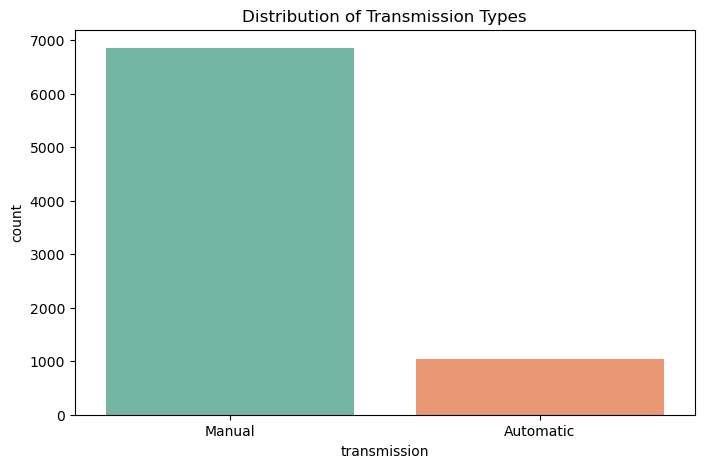

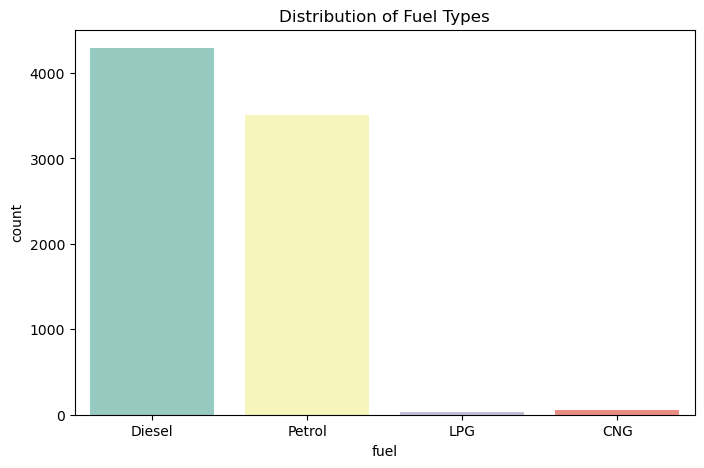


========== Used Car Analytics Menu ==========
1. Summary Statistics and Key Metrics
2. Top 10 Most Listed Car Models
3. Cars Offering the Best Resale Value
4. Market Trends (Price vs Year/Mileage)
5. Buyer Preferences (Transmission/Fuel)
6. Exit
Enter your choice (1-6): 7
Invalid choice. Please select a number between 1 and 6.

========== Used Car Analytics Menu ==========
1. Summary Statistics and Key Metrics
2. Top 10 Most Listed Car Models
3. Cars Offering the Best Resale Value
4. Market Trends (Price vs Year/Mileage)
5. Buyer Preferences (Transmission/Fuel)
6. Exit
Enter your choice (1-6): 2

--- Top 10 Most Listed Car Models ---
Maruti        2367
Hyundai       1352
Mahindra       756
Tata           718
Honda          466
Toyota         452
Ford           388
Chevrolet      230
Renault        228
Volkswagen     183
Name: name, dtype: int64

========== Used Car Analytics Menu ==========
1. Summary Statistics and Key Metrics
2. Top 10 Most Listed Car Models
3. Cars Offering the Bes

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df['price_to_mileage_ratio'] = df['price'] / df['km_driven']

def show_summary_stats():
    print("\n--- Summary Statistics ---")
    print(df[['price', 'km_driven']].describe())
    print("\n--- Mode Statistics ---")
    print(df.mode().iloc[0])

def show_top_models():
    print("\n--- Top 10 Most Listed Car Models ---")
    top_10 = df['name'].value_counts().head(10)
    print(top_10)

def show_best_resale_value():
    print("\n--- Top 10 Cars with Best Resale Value ---")
    top_resale = df[['name', 'year', 'price', 'km_driven', 'price_to_mileage_ratio']] \
        .sort_values(by='price_to_mileage_ratio').head(10)
    print(top_resale)

def show_market_trends():
    print("\n--- Market Trends: Showing Price vs Year & Mileage ---")
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='year', y='price', hue='km_driven', palette='viridis')
    plt.title("Price vs Year Colored by KM Driven")
    plt.tight_layout()
    plt.show()

    sns.lmplot(data=df, x='year', y='price', aspect=2, height=6, line_kws={'color': 'red'})
    plt.title("Price Trend Over the Years")
    plt.show()

def show_buyer_preferences():
    print("\n--- Buyer Preferences: Transmission and Fuel Type Distribution ---")
    plt.figure(figsize=(8, 5))
    sns.countplot(x='transmission', data=df, palette='Set2')
    plt.title("Distribution of Transmission Types")
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.countplot(x='fuel', data=df, palette='Set3')
    plt.title("Distribution of Fuel Types")
    plt.show()

def menu():
    while True:
        print("\n========== Used Car Analytics Menu ==========")
        print("1. Summary Statistics and Key Metrics")
        print("2. Top 10 Most Listed Car Models")
        print("3. Cars Offering the Best Resale Value")
        print("4. Market Trends (Price vs Year/Mileage)")
        print("5. Buyer Preferences (Transmission/Fuel)")
        print("6. Exit")
        
        choice = input("Enter your choice (1-6): ")

        if choice == '1':
            show_summary_stats()
        elif choice == '2':
            show_top_models()
        elif choice == '3':
            show_best_resale_value()
        elif choice == '4':
            show_market_trends()
        elif choice == '5':
            show_buyer_preferences()
        elif choice == '6':
            print("Thank you! Exiting...")
            break
        else:
            print("Invalid choice. Please select a number between 1 and 6.")

# Run the menu
menu()


In [1]:
from sqlalchemy import create_engine, text

# Replace with your actual connection string
engine = create_engine('sqlite:///UsedCarsDB')

# Name of the table to drop
table_name = 'used_cars'

with engine.connect() as conn:
    conn.execute(text(f"DROP TABLE IF EXISTS {table_name}"))
    print(f"✅ Table '{table_name}' dropped successfully.")


✅ Table 'used_cars' dropped successfully.
